Dataset structure should be:

<pre>
data
    yes
        ...
    no
        ...

excel
    excel_file.xlsx (doesn't matter what the file is called)
</pre>

In [1]:
!pip install openpyxl

In [2]:
# Imports and set seed
import os
SEED = 1337
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
os.environ["PYTHONHASHSEED"] = str(SEED)

import random
import numpy as np
import torch
# Seed Python, NumPy, and PyTorch (CPU & CUDA)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# cuDNN and matmul knobs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
except Exception:
    pass

# Enforce deterministic ops
torch.use_deterministic_algorithms(True)
print(f"Determinism configured with SEED={SEED}")

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from PIL import Image
import torch.nn.functional as F
from collections import Counter
import matplotlib.pyplot as plt

# Used to process the excel data
import pandas as pd
import shutil

Determinism configured with SEED=1337


In [3]:
def excel_to_data(data_dir):
    file_name = os.listdir(data_dir)[0] # First file in the folder
    print(file_name)
    excel_file = pd.ExcelFile(data_dir + '/' + file_name)
    names = [[], []] # names[0] all the "yes", names[1] all the "no"
    scenes = ['40753679', '47333462', '47333473']
    sheets = excel_file.sheet_names
    for s in scenes:
        if s in sheets:
            df = pd.read_excel(data_dir + '/' + file_name, sheet_name = s)
            for i in range(len(df["frame_index"])):
                name = s + '_'
                name += df["query"][i] + '_'
                name += str(df["frame_index"][i]) + '_'
                name += "rendered.png"
                if df["object_present"][i] == True:
                    names[0].append(name)
                else:
                    names[1].append(name)
    print(f"Found {len(names[0])} TRUE")
    print(f"Found {len(names[1])} FALSE")

    # Copy the files from E_grade_pics to data
    copied = [0, 0]
    queries = os.listdir("E_grade_pics")
    for q in queries:
        pic_names = os.listdir("E_grade_pics/" + q)
        for correct in [0, 1]:
            for name in names[correct]:
                if name in pic_names:
                    copied[correct] += 1
                    source_path = "E_grade_pics/" + q + '/' + name
                    if correct == 0:
                        destination_path = "data/yes/" + name
                    else:
                        destination_path = "data/no/" + name
                    shutil.copyfile(source_path, destination_path)
                elif name[-12:] == "rendered.png" and len(name.split('_')) == 4:
                    if name.split('_')[1] == q:
                        print(f"File {name} not found in excel data")
    
    print(f"Copied {copied[0]} files into yes")
    print(f"Copied {copied[1]} files into no")
    return None
    


In [4]:
def get_queries(data_dir):
    files = []
    for folder in ['yes', 'no']:
        dir = data_dir + '/' + folder
        files += os.listdir(dir)
    
    queries = []
    for f in files:
        q = f.split("_")[1]
        if q not in queries:
            queries.append(q)
    return queries

In [5]:
def run_one_epoch(model, dl, device, criterion, opt):
    # train
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in dl["train"]:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += y.size(0)
    train_loss = loss_sum / total
    train_acc  = correct / total

    # val
    model.eval()
    total = correct = 0
    with torch.no_grad():
        for x, y in dl["val"]:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    val_acc = correct / total
    return train_loss, train_acc, val_acc


In [28]:
def predict_yes_no(img_path, data_dir="data", ckpt="yesno_resnet.pt"):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Class order from your folder names (e.g., ['no', 'yes'])
    classes = datasets.ImageFolder(data_dir).classes
    num_classes = len(classes)

    # Build the same model and load weights
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.to(device)
    model.eval()

    # Same preprocessing as training
    ORIG_H, ORIG_W = 600, 600
    cut_w = ORIG_W - 17*2
    cut_h = ORIG_H - 88*2
    border_crop = transforms.CenterCrop((cut_h, cut_w))
    #norm = ([0.485,0.456,0.406],[0.229,0.224,0.225])
    mean = [0.23986077308654785, 0.6361415386199951, 0.47133398056030273]
    std = [0.162283256649971, 0.14299844205379486, 0.10616453737020493]
    norm = (mean, std)
    tfm = transforms.Compose([
        border_crop,
        transforms.Resize((224, 224)),
        transforms.ToTensor(), transforms.Normalize(*norm)
    ])

    img = Image.open(img_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        idx = int(probs.argmax().item())
    return classes[idx], float(probs[idx])  # e.g., ('yes', 0.93)

In [7]:
#excel_to_data("excel") # UNCOMMENT this to load the excel data into "data"

In [8]:
data_dir = "data"
BATCH_SIZE = 64
device = "cuda" if torch.cuda.is_available() else "cpu"

ORIG_H, ORIG_W = 600, 600
cut_w = ORIG_W - 17*2
cut_h = ORIG_H - 88*2
border_crop = transforms.CenterCrop((cut_h, cut_w))
#norm = ([0.485,0.456,0.406],[0.229,0.224,0.225])
mean = [0.23986077308654785, 0.6361415386199951, 0.47133398056030273]
std = [0.162283256649971, 0.14299844205379486, 0.10616453737020493]
norm = (mean, std)
train_tfm = transforms.Compose([
    border_crop,
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(*norm)
])
val_tfm = transforms.Compose([
    border_crop,
    transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize(*norm)
])

# Load all images; labels are inferred from folder names ('yes','no')
ds_full = datasets.ImageFolder(data_dir)
print("class_to_idx:", ds_full.class_to_idx)  # {'no': 0, 'yes': 1} (order may vary)

# 80/20 train/val split per class
targets = ds_full.targets
train_idx, val_idx = [], []
for c in set(targets):
    idxs = [i for i,t in enumerate(targets) if t == c]
    random.shuffle(idxs)
    n_train = int(0.8 * len(idxs))
    train_idx += idxs[:n_train]
    val_idx   += idxs[n_train:]

train_ds = Subset(datasets.ImageFolder(data_dir, transform=train_tfm), train_idx)
val_ds = Subset(datasets.ImageFolder(data_dir, transform=val_tfm), val_idx)


# Deterministic DataLoader seeding (per-worker) and deterministic shuffling
g = torch.Generator()
g.manual_seed(SEED)

def _seed_worker(worker_id: int):
    worker_seed = SEED + worker_id
    import random, numpy as _np, torch as _torch
    random.seed(worker_seed)
    try:
        _np.random.seed(worker_seed)
    except Exception:
        pass
    _torch.manual_seed(worker_seed)

dl = {
  "train": DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True),
  "val":   DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True),
}

class_to_idx: {'no': 0, 'yes': 1}


In [9]:
# Create model and train it
use_pretrained_net = False
num_classes = len(ds_full.classes) # =2

weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained_net else None
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.to(device)

epoch_list = [25]
lr_list = [1e-3]
w_d_list = [5e-4] # = 5e-2
layer_list = [["all"]]

if not use_pretrained_net:
    epoch_list = [25]
    lr_list = [1e-3]
    w_d_list = [5e-4] # = 5e-2
    layer_list = [["all"]]

plot_train_acc = []
plot_val_acc = []
plot_epoch = []
best_val_acc = [-1.0, -1]
for i in range(len(epoch_list)):
    lr = lr_list[i]
    w_d = w_d_list[i]
    epochs = epoch_list[i]

    RESNET18_LAYER_NAMES = ["layer1", "layer2", "layer3", "layer4", "fc"]
    layers_to_train = layer_list[i]
    for name, param in model.named_parameters():
        top = name.split('.', 1)[0]
        if top in layers_to_train or layers_to_train == ["all"]:
            param.requires_grad = True
        else:
            param.requires_grad = False

    print(f"Training layers {layers_to_train}")

    train_targets = torch.tensor([ds_full.targets[i] for i in train_idx])
    class_counts = torch.bincount(train_targets, minlength=num_classes)
    class_weights = (class_counts.sum() / class_counts.clamp_min(1)).float()
    class_weights = class_weights / class_weights.mean()
    class_weights = class_weights.to(device)
    print("class_counts:", class_counts.tolist())
    print("class_weights:", [round(w, 3) for w in class_weights.tolist()])
    
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or n.endswith(".bias"):   # 1D → norm scales & biases
            no_decay.append(p)
        else:
            decay.append(p)
    param_groups = [{"params": decay, "weight_decay": w_d}, {"params": no_decay, "weight_decay": 0.0}]
    
    opt = optim.AdamW(param_groups, lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, val_acc = run_one_epoch(model, dl, device, criterion, opt)
        sched.step()
        is_best = val_acc > best_val_acc[0]
        if is_best:
            best_val_acc[0] = val_acc
            best_val_acc[1] = epoch + sum(epoch_list[0:i])
            torch.save(model.state_dict(), "yesno_resnet.pt")
        print(f"epoch {epoch}: loss {train_loss:.4f}, train acc {train_acc:.3f}, val acc {val_acc:.3f}"
            + ("  [saved]" if is_best else ""))
        plot_train_acc.append(train_acc)
        plot_val_acc.append(val_acc)
        plot_epoch.append(epoch + sum(epoch_list[0:i]))
        
print(f"Best val acc {best_val_acc[0]}")


Training layers ['all']
class_counts: [1012, 549]
class_weights: [0.703, 1.297]
epoch 1: loss 0.6914, train acc 0.696, val acc 0.430  [saved]
epoch 2: loss 0.5843, train acc 0.730, val acc 0.739  [saved]
epoch 3: loss 0.5589, train acc 0.739, val acc 0.772  [saved]
epoch 4: loss 0.5552, train acc 0.751, val acc 0.734
epoch 5: loss 0.5365, train acc 0.762, val acc 0.767
epoch 6: loss 0.5242, train acc 0.760, val acc 0.785  [saved]
epoch 7: loss 0.5094, train acc 0.769, val acc 0.785
epoch 8: loss 0.5294, train acc 0.781, val acc 0.801  [saved]
epoch 9: loss 0.5001, train acc 0.785, val acc 0.747
epoch 10: loss 0.4762, train acc 0.805, val acc 0.824  [saved]
epoch 11: loss 0.4603, train acc 0.804, val acc 0.790
epoch 12: loss 0.4681, train acc 0.812, val acc 0.831  [saved]
epoch 13: loss 0.4608, train acc 0.814, val acc 0.818
epoch 14: loss 0.4462, train acc 0.816, val acc 0.829
epoch 15: loss 0.4418, train acc 0.829, val acc 0.818
epoch 16: loss 0.4344, train acc 0.835, val acc 0.841  [

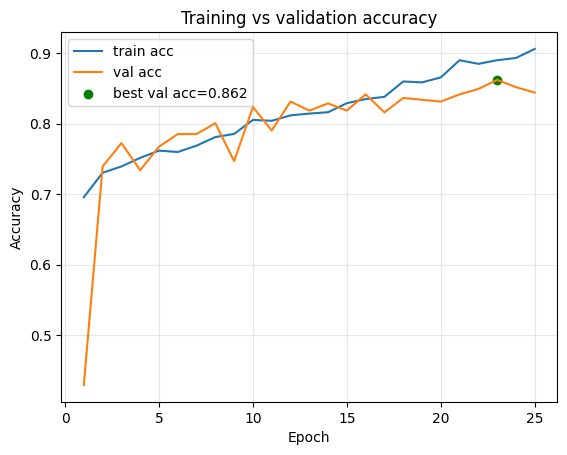

In [10]:
plt.plot(plot_epoch, plot_train_acc, label="train acc")
plt.plot(plot_epoch, plot_val_acc, label="val acc")
plt.scatter(best_val_acc[1], best_val_acc[0], color="green", label=f"best val acc={best_val_acc[0]:.3f}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Training vs validation accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [11]:
# Copy all the guesses to a folder
folder = "Validation"
sub_folder1 = f"{folder}/correct"
sub_folder2 = f"{folder}/incorrect"
os.makedirs(folder, exist_ok=True)

# Delete all files in the folder
for name in os.listdir(folder):
    path = os.path.join(folder, name)
    if os.path.isfile(path) or os.path.islink(path):
        os.remove(path)
    elif os.path.isdir(path):
        shutil.rmtree(path)

os.makedirs(sub_folder1, exist_ok=True)
os.makedirs(f"{sub_folder1}/yes", exist_ok=True)
os.makedirs(f"{sub_folder1}/no", exist_ok=True)
os.makedirs(sub_folder2, exist_ok=True)
os.makedirs(f"{sub_folder2}/yes", exist_ok=True)
os.makedirs(f"{sub_folder2}/no", exist_ok=True)

base = val_ds.dataset
idxs = val_ds.indices
samples = getattr(base, "samples", getattr(base, "imgs"))

wrong = 0
right = 0
total = len(idxs)
counter = 0
for i in idxs:
    counter += 1
    print(f"\r{counter} / {total}", end="")
    name = samples[i][0]
    ground_truth = name.split('/')[1]
    predicted = predict_yes_no(name)[0]
    if ground_truth == predicted:
        right += 1
        shutil.copyfile(name, f"{sub_folder1}/{ground_truth}/{name.split('/')[-1]}")
    else:
        wrong += 1
        shutil.copyfile(name, f"{sub_folder2}/{ground_truth}/{name.split('/')[-1]}")
print("")
print(f"Correct: {right}, Incorrect: {wrong}, Total: {total}, Acc: {(right/total):.3f}")

1 / 391

/tmp/ipykernel_507/4285757208.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device))


391 / 391
Correct: 337, Incorrect: 54, Total: 391, Acc: 0.862


In [12]:
# Add the RGB images to the guess folder
copied = 0
queries = os.listdir("E_grade_pics")
for f in [f"{sub_folder1}/yes", f"{sub_folder1}/no", f"{sub_folder2}/yes", f"{sub_folder2}/no"]:
    for name in os.listdir(f):
        for q in queries:
            if name in os.listdir(f"E_grade_pics/{q}"):
                rgb_name = name.split('_')
                if len(rgb_name) > 3:
                    if rgb_name[3] == "rendered.png":
                        rgb_name[3] = "rgb.png"
                        rgb_name = '_'.join(rgb_name)
                        shutil.copyfile(f"E_grade_pics/{q}/{rgb_name}", f"{f}/{rgb_name}")
                        copied += 1
print(copied)


391


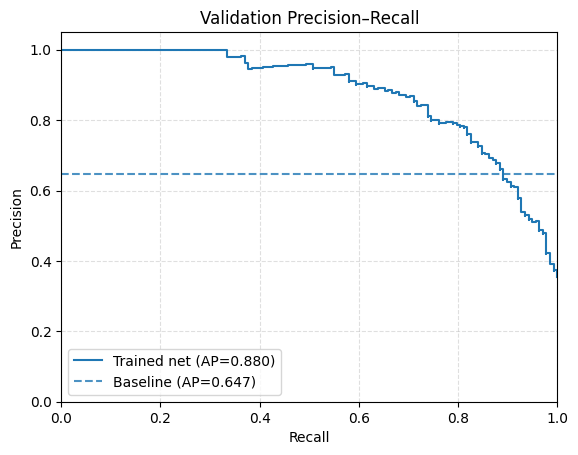

In [13]:
# --- Precision–Recall curve on validation set (uses dl["val"]) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

model.eval()

# Get class order and pick "yes" as the positive class (fallback to index 1 if not present)
classes = datasets.ImageFolder(data_dir).classes
pos_cls = "yes" if "yes" in classes else (classes[1] if len(classes) > 1 else classes[0])
pos_idx = classes.index(pos_cls)

y_true, y_scores = [], []

with torch.no_grad():
    for x, y in dl["val"]:
        x = x.to(device)
        # probability of the positive class
        probs = torch.softmax(model(x), dim=1)[:, pos_idx].cpu().numpy()
        y_scores.append(probs)
        y_true.append((y == pos_idx).int().cpu().numpy())

y_true   = np.concatenate(y_true)
y_scores = np.concatenate(y_scores)

prec, rec, _ = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)

baseline = float(1 - np.mean(y_true))

plt.figure()
plt.step(rec, prec, where="post", label=f"Trained net (AP={ap:.3f})")
plt.hlines(baseline, 0, 1, linestyles="--", label=f"Baseline (AP={baseline:.3f})", alpha=0.8)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Validation Precision–Recall")
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="lower left")
plt.show()


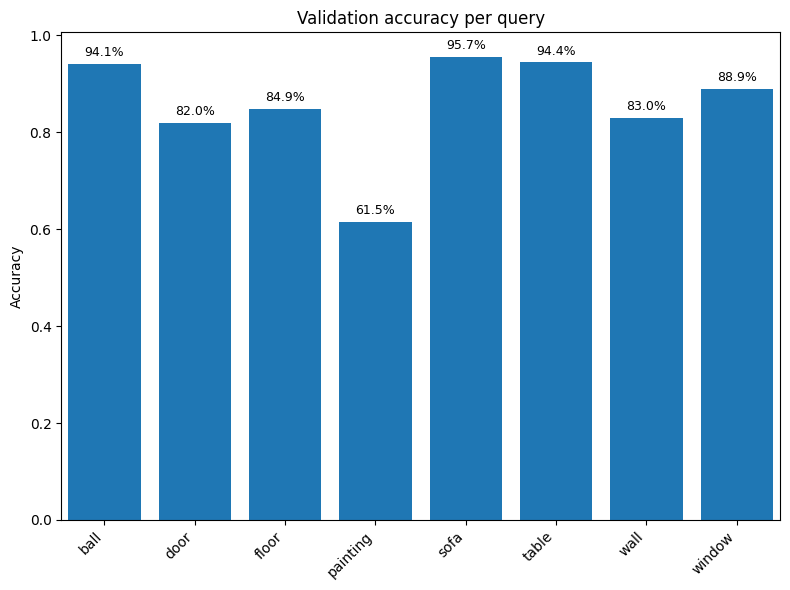

Saved: val_query_accuracy.csv and val_query_accuracy.png


In [40]:
import os, pandas as pd, matplotlib.pyplot as plt

def filenames_in(root):
    out = []
    if not os.path.isdir(root):
        return out
    for sub in os.listdir(root):
        p = os.path.join(root, sub)
        if os.path.isdir(p):
            for f in os.listdir(p):
                out.append(os.path.join(p, f))
    return out

corr = filenames_in("Validation/correct")
inc  = filenames_in("Validation/incorrect")

rows = []
for p in corr:
    q = os.path.basename(p).split("_")[1]
    rows.append((q, 1))
for p in inc:
    q = os.path.basename(p).split("_")[1]
    rows.append((q, 0))

df = pd.DataFrame(rows, columns=["query", "correct"])
acc = (
    df.groupby("query")
      .agg(n=("correct", "size"), accuracy=("correct", "mean"))
      .reset_index()
      #.sort_values(["accuracy", "n", "query"], ascending=[False, False, True])
)

plt.figure(figsize=(max(8, len(acc) * 0.5), 6))
bars = plt.bar(acc["query"], acc["accuracy"])

plt.ylabel("Accuracy")
plt.title("Validation accuracy per query")
plt.xticks(rotation=45, ha="right")
plt.margins(x=0.01)

# Make a little headroom for labels
ymax = max(1.0, float(acc["accuracy"].max()) + 0.05)
plt.ylim(0, min(1.05, ymax))

# Add labels: show as percentages (e.g., 92.3%)
label_offset = 0.01 * plt.ylim()[1]
for b in bars:
    h = b.get_height()
    plt.text(
        b.get_x() + b.get_width() / 2,
        h + label_offset,
        f"{h:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()
print("Saved: val_query_accuracy.csv and val_query_accuracy.png")
